In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp
# из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки matplotlib.animation
import matplotlib.animation as animation

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения первых производных в (8.43)
def Oscillator(t, z):
    # инициализация массива, используемого для
    # хранения значений первых производных
    dy = np.zeros(4)

    D = m1 + m2 * np.sin(z[0] - z[2]) ** 2
    dy[0] = z[1]
    dy[1] = -(
        m2 * L2 * np.sin(z[0] - z[2]) * z[3] ** 2 + (m1 + m2) * g * np.sin(z[0])
    ) - (m2 * L1 * np.sin(z[0] - z[2]) * z[1] ** 2 - m2 * g * np.sin(z[2])) * np.cos(
        z[0] - z[2]
    )
    dy[1] = dy[1] / (L1 * D)
    dy[2] = z[3]
    dy[3] = (L1 * np.sin(z[0] - z[2]) * z[1] ** 2 - g * np.sin(z[2])) * (m1 + m2) + (
        m2 * L2 * np.sin(z[0] - z[2]) * z[3] ** 2 + (m1 + m2) * g * L1 * np.sin(z[0])
    ) * np.cos(z[0] - z[2])
    dy[3] = dy[3] / (L2 * D)
    return dy

In [ ]:
# Ячейка № 3

# задание значения ускорения свободного падения
g = 9.8

# задание длины первого маятника
L1 = 1

# задание длины второго маятника
L2 = 2

# задание массы первого маятника
m1 = 10

# задание массы второго маятника
m2 = 5

# задание начального угла отклонения
# математического маятника от вертикали

# задание длительности временного интервала,
# на котором вычисляется численное решение СДУ (8.43)
N = 10**4
Tmax = 10

# задание шага временной сетки,
# используемой для нахождения
# численного решения СДУ (8.42)
dt = Tmax / N

# вычисление численного решения СДУ (8.43)
# с начальными условиями:
# phi1(0)=pi/4, dhpi1_dt(0)=0,
# phi2(0)=2*pi/3, dphi2_dy(0)=0
Solv = solve_ivp(Oscillator, [0, Tmax], [np.pi / 4, 0, 2 * np.pi / 3, 0], max_step=dt)

"""
# вычисление численного решения СДУ (8.43)
# с начальными условиями:
# phi1(0)=pi/4, dhpi1_dt(0)=0,
# phi2(0)=2*pi/3, dphi2_dy(0)=0
Solv =solve_ivp(Oscillator,[0,Tmax],\
              [np.pi/4,0, 2*np.pi/3, 0],max_step = dt)
"""

# размещение значений координат узлов
# временной сетки, на которой найдены численные решения
# системы ОДУ (8.4) в массив t
t = Solv.t
# определение числа узлов временной сетки
Np = len(t)

# размещение мгновенных значений
# угла отклонения математического маятника
# от вертикали в массив phi1
phi1 = Solv.y[0, :]

# размещение мгновенных значений
# угловой скорости математического маятника
# составляющей скорости в массив dphi_dt1
dphi1_dt = Solv.y[1, :]

# размещение мгновенных значений
# угла отклонения математического маятника
# от вертикали в массив phi2
phi2 = Solv.y[2, :]

# размещение мгновенных значений
# угловой скорости математического маятника
# составляющей скорости в массив dphi_dt2
dphi2_dt = Solv.y[3, :]

# инициализация массивов, используемых
# для хранения мгновенных значений
# декартовых координат масс m1, m2
x1 = np.zeros(Np)
y1 = np.zeros(Np)
x2 = np.zeros(Np)
y2 = np.zeros(Np)
X2 = np.zeros(Np)
Y2 = np.zeros(Np)

# вычисление декартовых координат
# математического маятника
for i in range(Np):
    # Квадрант I
    if (phi1[i] >= 0) & (phi1[i] >= np.pi / 2):
        x1[i] = L1 * np.sin(np.pi - phi1[i])
        y1[i] = L1 * np.cos(np.pi - phi1[i])
    # Квадрант II
    if (phi1[i] < 0) & (np.abs(phi1[i]) >= np.pi / 2):
        x1[i] = -L1 * np.sin(np.pi - np.abs(phi1[i]))
        y1[i] = L1 * np.cos(np.pi - np.abs(phi1[i]))
    # Квадрант III
    if (phi1[i] < 0) & (np.abs(phi1[i]) < np.pi / 2):
        x1[i] = -L1 * np.sin(np.abs(phi1[i]))
        y1[i] = -L1 * np.cos(np.abs(phi1[i]))
    # Квадрант IV
    if (phi1[i] > 0) & (phi1[i] <= np.pi / 2):
        x1[i] = L1 * np.sin(phi1[i])
        y1[i] = -L1 * np.cos(phi1[i])

    # Квадрант I
    if (phi2[i] >= 0) & (phi2[i] >= np.pi / 2):
        X2[i] = L2 * np.sin(np.pi - phi2[i])
        Y2[i] = L2 * np.cos(np.pi - phi2[i])
    # Квадрант II
    if (phi2[i] < 0) & (np.abs(phi2[i]) >= np.pi / 2):
        X2[i] = -L2 * np.sin(np.pi - np.abs(phi2[i]))
        Y2[i] = L2 * np.cos(np.pi - np.abs(phi2[i]))
    # Квадрант III
    if (phi2[i] < 0) & (np.abs(phi2[i]) < np.pi / 2):
        X2[i] = -L2 * np.sin(np.abs(phi2[i]))
        Y2[i] = -L2 * np.cos(np.abs(phi2[i]))
    # Квадрант IV
    if (phi2[i] > 0) & (phi2[i] <= np.pi / 2):
        X2[i] = L2 * np.sin(phi2[i])
        Y2[i] = -L2 * np.cos(phi2[i])
    x2[i] = x1[i] + X2[i]
    y2[i] = y1[i] + Y2[i]

# инициализация массивов, используемых
# для хранения мгновенных значений
# кинетической и потенциальных энергий масс m1, m2
# полной энергии системы
T1 = np.zeros(Np)
U1 = np.zeros(Np)
T2 = np.zeros(Np)
U2 = np.zeros(Np)
E = np.zeros(Np)

# вычисление кинетической энергии массы m1
T1 = m1 / 2 * L1**2 * dphi1_dt**2

# вычисление потенциальной энергии массы m1
U1 = -m1 * g * (L1 - y1)

# вычисление кинетической энергию массы m2
T2 = (
    m2
    / 2
    * (
        L1**2 * dphi1_dt**2
        + L2**2 * dphi2_dt**2
        + 2 * L1 * L2 * np.cos(phi1 - phi2) * dphi1_dt * dphi2_dt
    )
)

# вычисление потенциальной энергии массы m2
U2 = -m2 * g * (L1 + L2 - y2)

# вычисление полной энергии двойного маятника
E = T1 + U1 + T2 + U2

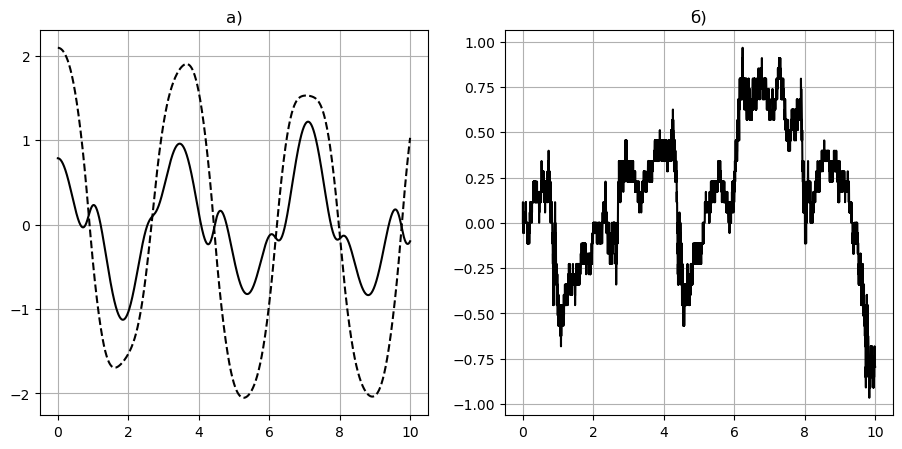

In [4]:
# Ячейка № 4

# визуализация зависимости угла
# отклонения математического маятника
# от вертикали
fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t, phi1, "black")
ax.plot(t, phi2, "--", color="black")
ax.grid(True)
ax.set_title("а)")

# визуализация зависимости x=x(t)
ax = fig.add_subplot(1, 2, 2)
ax.plot(t[:], (E[:] - E[0]) * 10**12, "black")
ax.grid(True)
ax.set_title("б)")

plt.show()

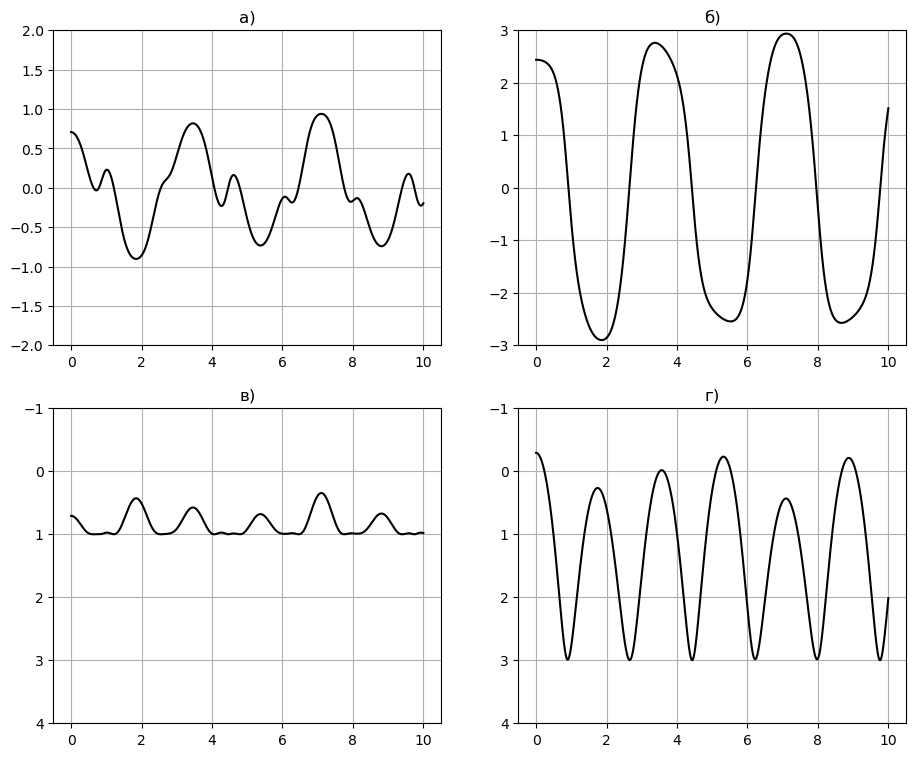

In [5]:
# Ячейка № 5

# визуализация зависимости абсциссы
# массы m1 от времени
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(2, 2, 1)
ax.plot(t, x1, "black")
ax.set_ylim(-2, 2.0)
ax.grid(True)
ax.set_title("а)")

# визуализация зависимости абсциссы
# массы m2 от времени
ax = fig.add_subplot(2, 2, 2)
ax.plot(t, x2, "black")
ax.set_ylim(-3.0, 3.0)
ax.grid(True)
ax.set_title("б)")

# визуализация зависимости ординаты
# массы m1 от времени
ax = fig.add_subplot(2, 2, 3)
ax.plot(t, -y1, "black")
ax.set_ylim(4.0, -1.0)
ax.grid(True)
ax.set_title("в)")

# визуализация зависимости ординаты
# массы m2 от времени
ax = fig.add_subplot(2, 2, 4)
ax.plot(t, -y2, "black")
ax.set_ylim(4.0, -1.0)
ax.grid(True)
ax.set_title("г)")

plt.show()

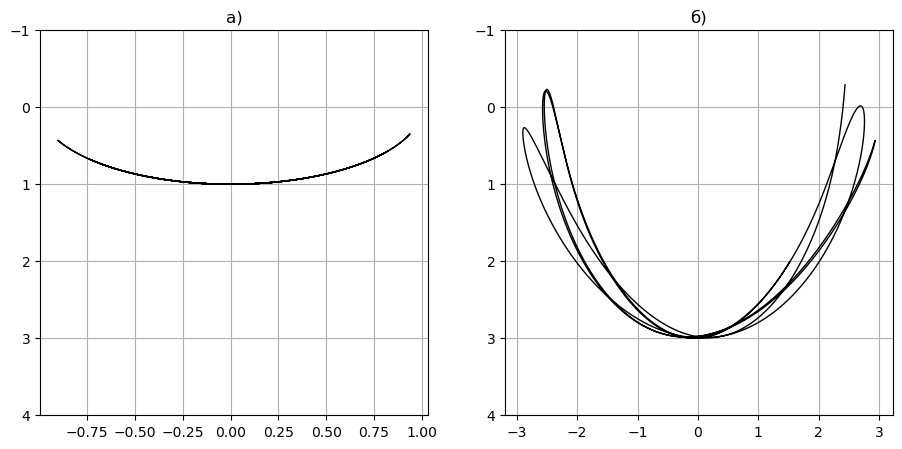

In [6]:
# Ячейка № 6

# визуализация траектории движения массы m1
fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x1, -y1, "-k", lw=1)
ax.set_ylim(4.0, -1.0)
ax.grid(True)
ax.set_title("а)")


# визуализация траектории движения массы m2
ax = fig.add_subplot(1, 2, 2)
ax.plot(x2, -y2, "-k", lw=1)
ax.set_ylim(4.0, -1.0)
ax.grid(True)
ax.set_title("б)")

plt.show()

In [7]:
# Ячейка № 5

# создание анимационного клипа

fig = plt.figure(figsize=(9, 5))
ax = fig.add_subplot()


# анимация зависимости угла отклонения
# математического маятника от вертикали
def animate(i):
    nf = 50

    ax.clear()
    ax.grid(True)
    ax.tick_params(labelsize=10)
    ax.set_xlim(-3.0, 3.0)
    ax.set_ylim(4.0, -1.0)

    O1 = [0, 0]
    M1 = [x1[nf * i], -y1[nf * i]]
    O2 = M1
    M2 = [x2[nf * i], -y2[nf * i]]
    coord1 = list(zip(O1, M1))
    coord2 = list(zip(O2, M2))
    ax.plot(coord1[0], coord1[1], "black")
    ax.plot(x1[nf * i], -y1[nf * i], "ro")
    ax.plot(coord2[0], coord2[1], "black")
    ax.plot(x2[nf * i], -y2[nf * i], "ro")


# воспроизведение анимационного клипа
ani = animation.FuncAnimation(fig, animate, 200, interval=100, blit=False)
plt.close()

from IPython.display import HTML

HTML(ani.to_jshtml())